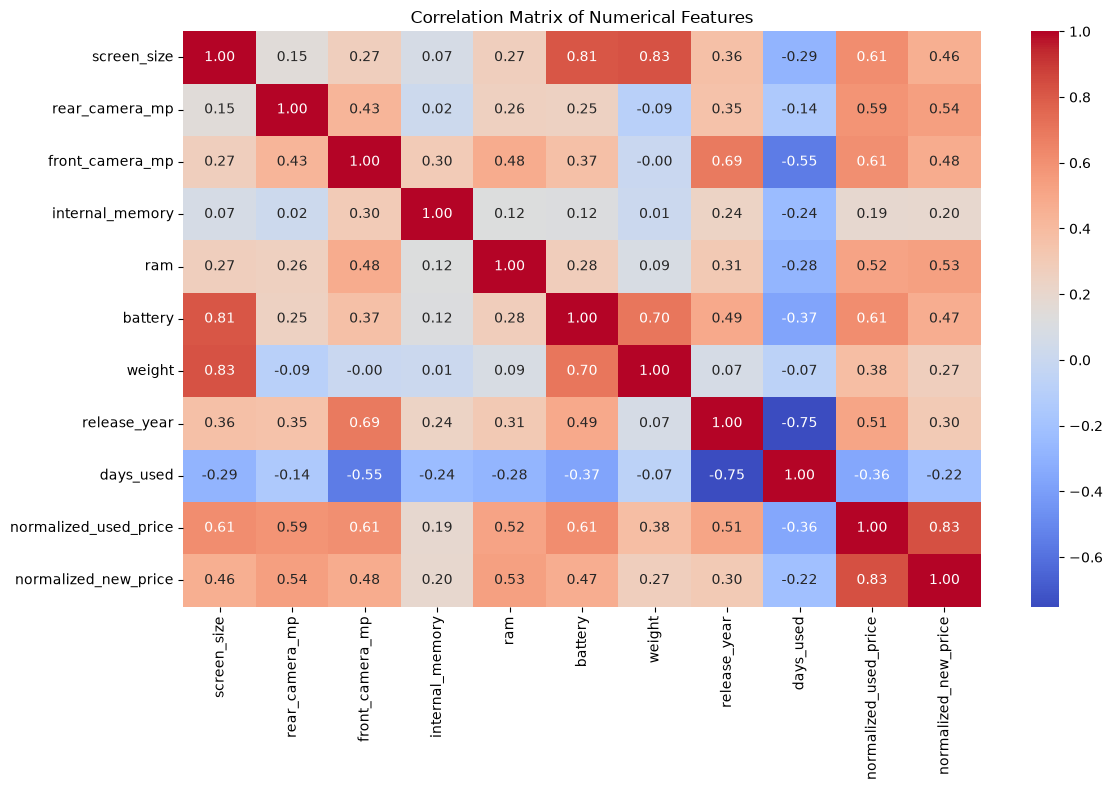

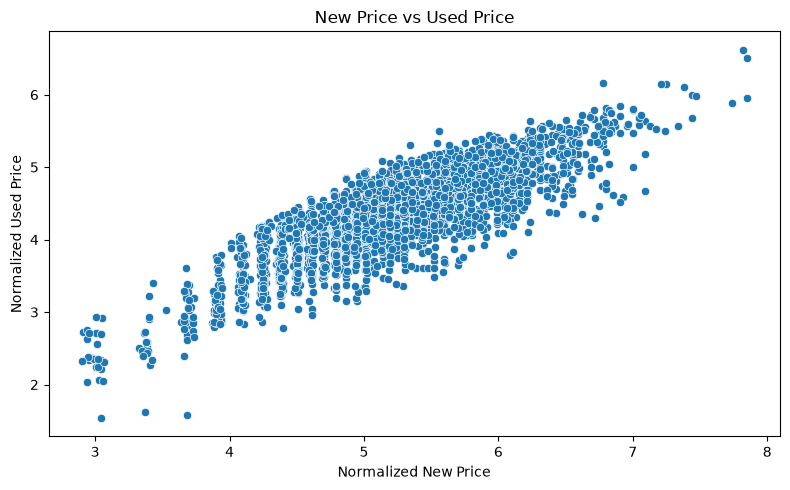

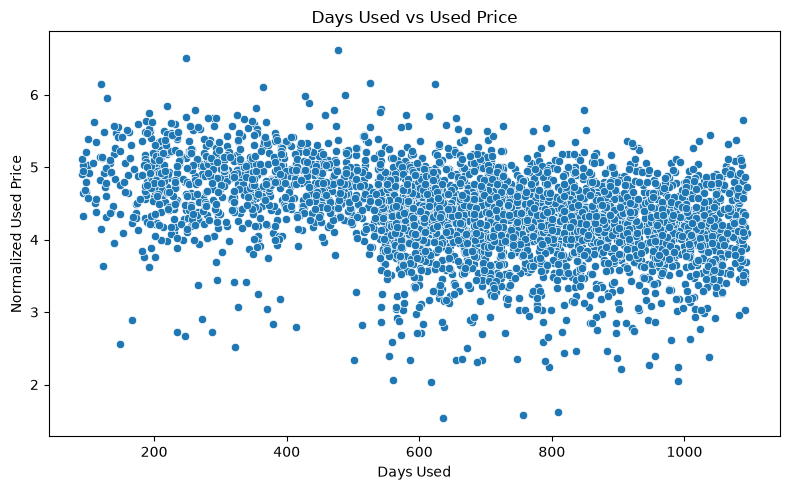

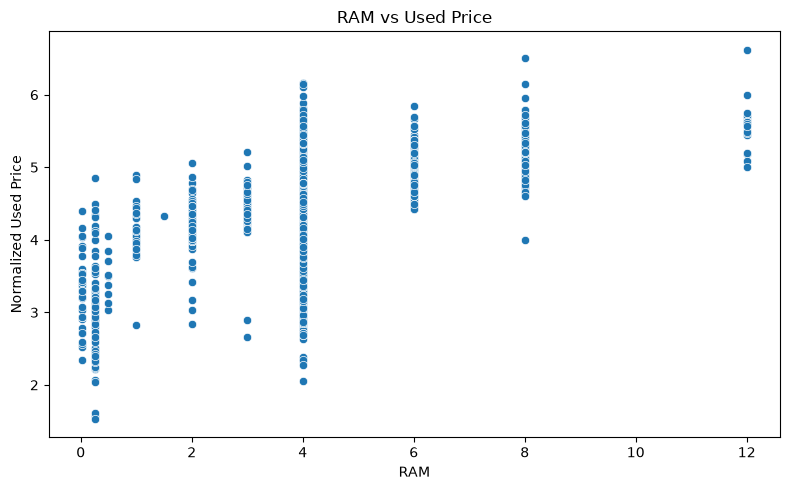

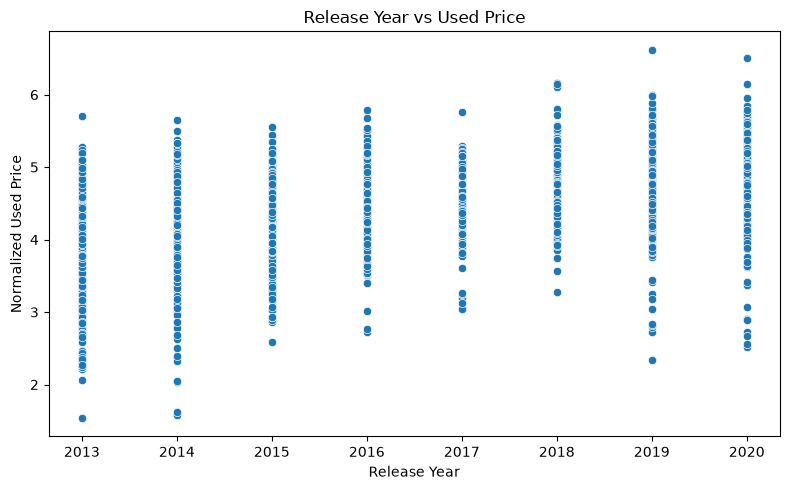

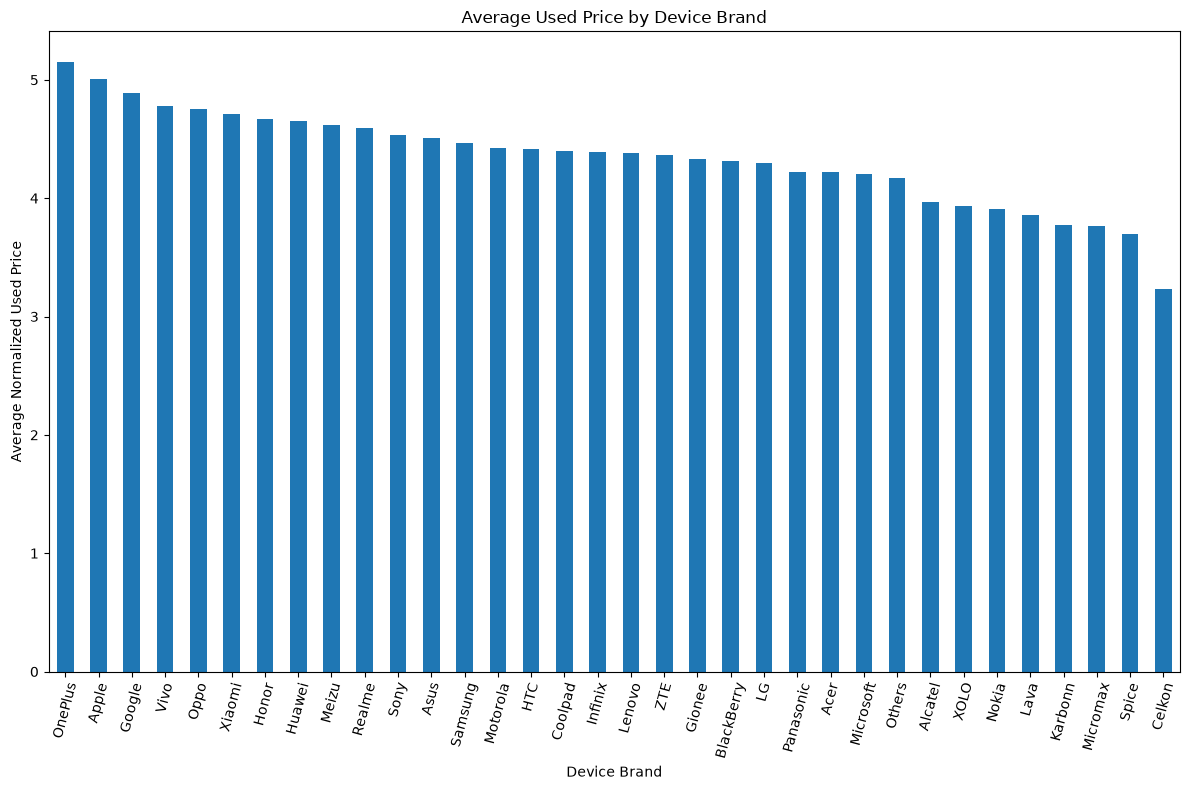

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(12, 8))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="normalized_new_price",
    y="normalized_used_price"
)

plt.title("New Price vs Used Price")
plt.xlabel("Normalized New Price")
plt.ylabel("Normalized Used Price")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="days_used",
    y="normalized_used_price"
)

plt.title("Days Used vs Used Price")
plt.xlabel("Days Used")
plt.ylabel("Normalized Used Price")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="ram",
    y="normalized_used_price"
)

plt.title("RAM vs Used Price")
plt.xlabel("RAM")
plt.ylabel("Normalized Used Price")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="release_year",
    y="normalized_used_price"
)

plt.title("Release Year vs Used Price")
plt.xlabel("Release Year")
plt.ylabel("Normalized Used Price")
plt.tight_layout()
plt.show()

brand_price = (
    df.groupby("device_brand")["normalized_used_price"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 8))

brand_price.plot(kind="bar")

plt.title("Average Used Price by Device Brand")
plt.xlabel("Device Brand")
plt.ylabel("Average Normalized Used Price")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [31]:
df_clean = df.copy()

print("Original shape:", df.shape)
print("Working shape:", df_clean.shape)

Original shape: (3454, 15)
Working shape: (3454, 15)


In [32]:
missing = df_clean.isnull().sum()

missing = missing[missing > 0]

print(missing)

rear_camera_mp     179
front_camera_mp      2
internal_memory      4
ram                  4
battery              6
weight               7
dtype: int64


In [33]:
numeric_columns = [
    "screen_size",
    "rear_camera_mp",
    "front_camera_mp",
    "internal_memory",
    "ram",
    "battery",
    "weight",
    "release_year",
    "days_used",
    "normalized_used_price",
    "normalized_new_price"
]

for col in numeric_columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Missing values after cleaning:")
print(df_clean.isnull().sum())

print("Shape:", df_clean.shape)
print("Duplicate rows:", df_clean.duplicated().sum())
print("Total missing values:", df_clean.isnull().sum().sum())

Missing values after cleaning:
device_brand             0
os                       0
screen_size              0
4g                       0
5g                       0
rear_camera_mp           0
front_camera_mp          0
internal_memory          0
ram                      0
battery                  0
weight                   0
release_year             0
days_used                0
normalized_used_price    0
normalized_new_price     0
dtype: int64
Shape: (3454, 15)
Duplicate rows: 0
Total missing values: 0


In [37]:
df_clean.describe().T

print("Release year range:",
      df_clean["release_year"].min(),
      "to",
      df_clean["release_year"].max())

print("Days used range:",
      df_clean["days_used"].min(),
      "to",
      df_clean["days_used"].max())

print("RAM range:",
      df_clean["ram"].min(),
      "to",
      df_clean["ram"].max())

print("Battery range:",
      df_clean["battery"].min(),
      "to",
      df_clean["battery"].max())


df_clean.to_csv("../data/used_device_data_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Release year range: 2013 to 2020
Days used range: 91 to 1094
RAM range: 0.02 to 12.0
Battery range: 500.0 to 9720.0
Cleaned dataset saved successfully!


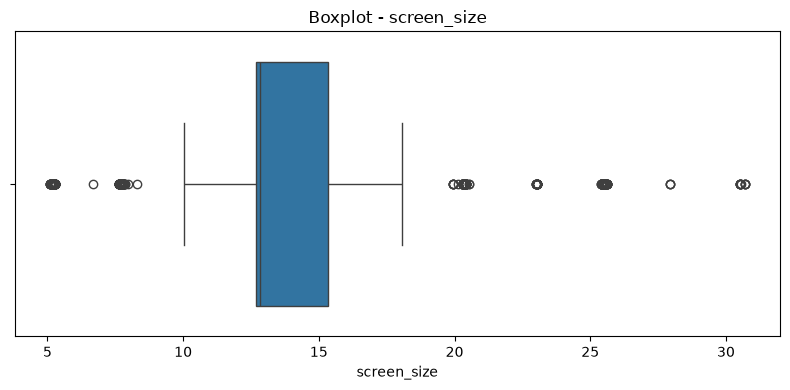

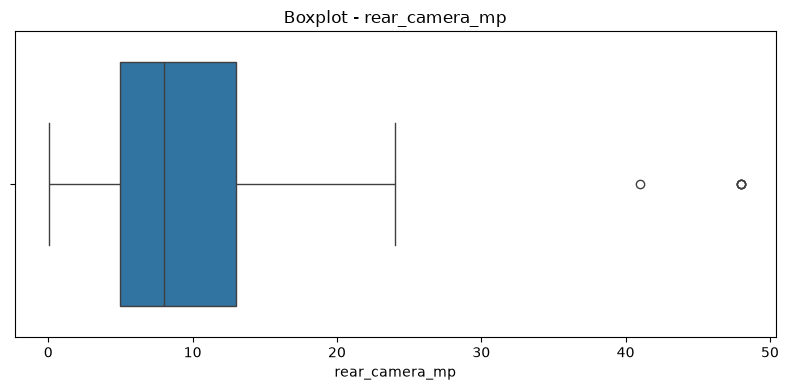

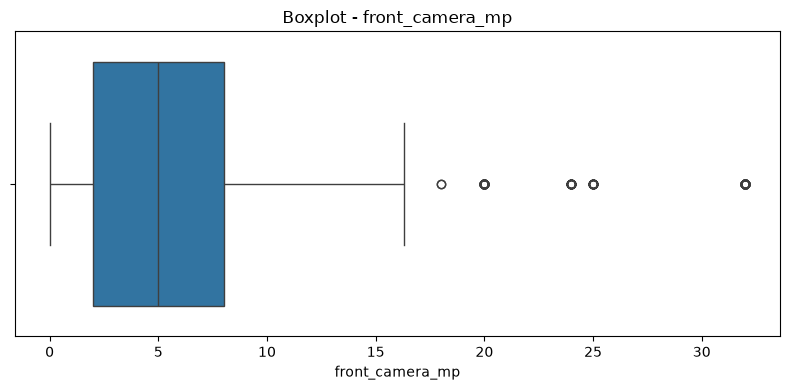

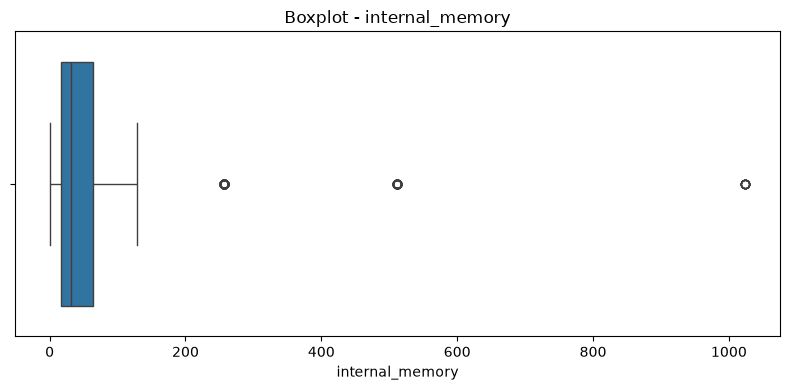

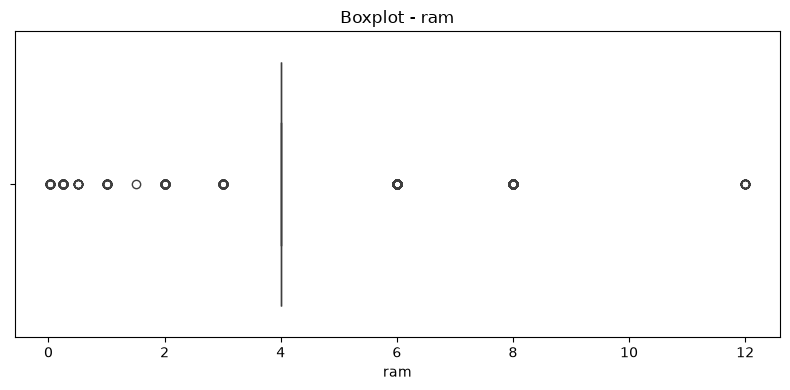

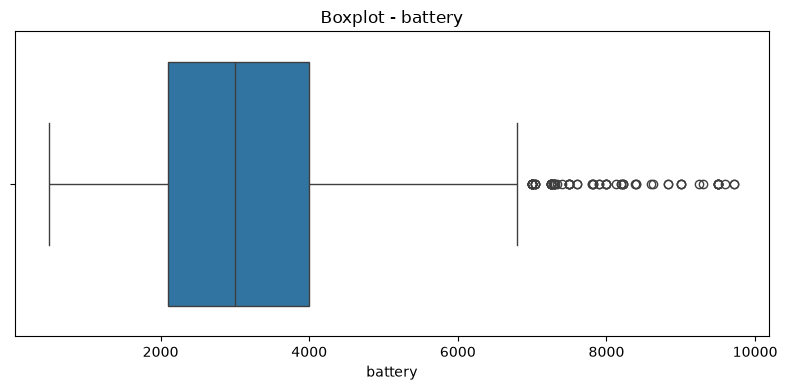

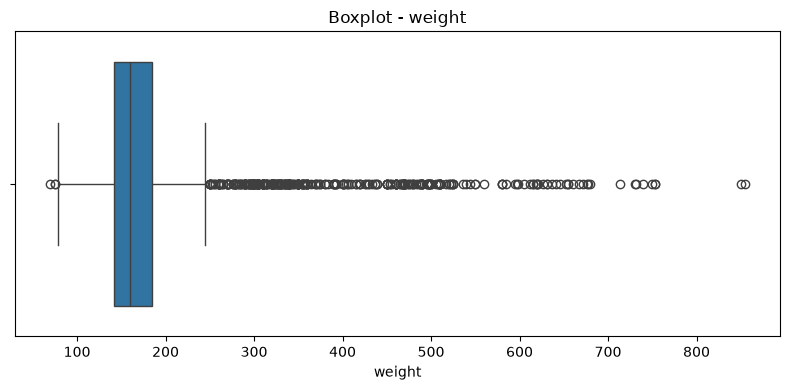

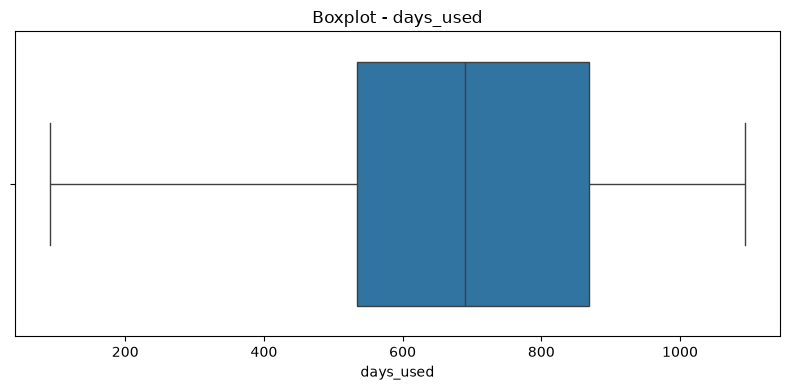

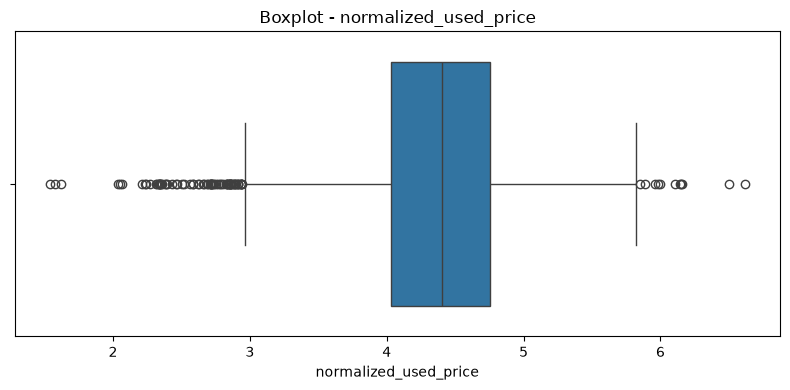

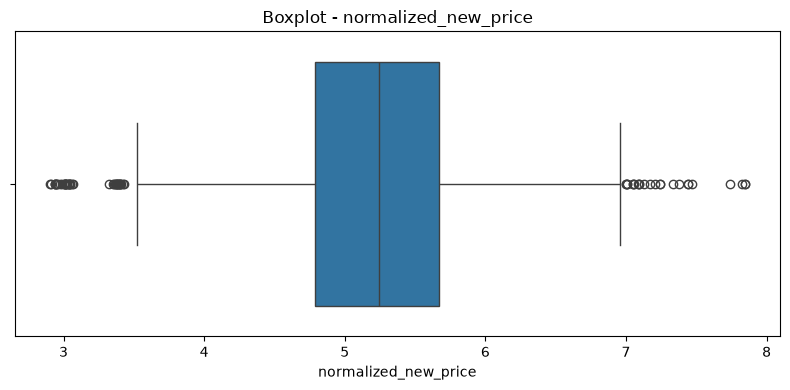


screen_size
Minimum : 5.08
Maximum : 30.71
Median  : 12.83

rear_camera_mp
Minimum : 0.08
Maximum : 48.0
Median  : 8.0

front_camera_mp
Minimum : 0.0
Maximum : 32.0
Median  : 5.0

internal_memory
Minimum : 0.01
Maximum : 1024.0
Median  : 32.0

ram
Minimum : 0.02
Maximum : 12.0
Median  : 4.0

battery
Minimum : 500.0
Maximum : 9720.0
Median  : 3000.0

weight
Minimum : 69.0
Maximum : 855.0
Median  : 160.0

days_used
Minimum : 91
Maximum : 1094
Median  : 690.5

normalized_used_price
Minimum : 1.53686722
Maximum : 6.619433002
Median  : 4.405132623

normalized_new_price
Minimum : 2.901421594
Maximum : 7.847840659
Median  : 5.2458918494999995
Used price:
Minimum : 1.53686722
Maximum : 6.619433002
Median  : 4.405132623

New price:
Minimum : 2.901421594
Maximum : 7.847840659
Median  : 5.2458918494999995


In [40]:
numeric_features = [
    "screen_size",
    "rear_camera_mp",
    "front_camera_mp",
    "internal_memory",
    "ram",
    "battery",
    "weight",
    "days_used",
    "normalized_used_price",
    "normalized_new_price"
]

for col in numeric_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df_clean[col])
    plt.title(f"Boxplot - {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

for col in numeric_features:
    print(f"\n{col}")
    print("Minimum :", df_clean[col].min())
    print("Maximum :", df_clean[col].max())
    print("Median  :", df_clean[col].median())

print("Used price:")
print("Minimum :", df_clean["normalized_used_price"].min())
print("Maximum :", df_clean["normalized_used_price"].max())
print("Median  :", df_clean["normalized_used_price"].median())

print("\nNew price:")
print("Minimum :", df_clean["normalized_new_price"].min())
print("Maximum :", df_clean["normalized_new_price"].max())
print("Median  :", df_clean["normalized_new_price"].median())

In [44]:
df_clean[df_clean["ram"] < 1][
    [
        "device_brand",
        "os",
        "screen_size",
        "internal_memory",
        "ram",
        "battery",
        "weight",
        "release_year",
        "days_used",
        "normalized_used_price"
    ]
]

df_clean[df_clean["screen_size"] > 20][
    [
        "device_brand",
        "os",
        "screen_size",
        "ram",
        "battery",
        "weight",
        "release_year"
    ]
]

low_ram = df_clean[df_clean["ram"] < 1]

print("Records with RAM below 1 GB:", len(low_ram))

low_ram[
    [
        "device_brand",
        "os",
        "screen_size",
        "internal_memory",
        "ram",
        "battery",
        "weight",
        "release_year",
        "days_used",
        "normalized_used_price",
        "normalized_new_price"
    ]
]

Records with RAM below 1 GB: 127


,device_brand,os,screen_size,internal_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
65,Lava,Android,12.70,8.00,0.50,3000.0,147.60,2016,819,3.495598,4.113003
96,LG,Android,7.62,4.00,0.50,1540.0,140.45,2014,750,3.027715,3.925926
103,Micromax,Android,10.16,0.50,0.25,1500.0,146.50,2014,1016,3.043570,3.926715
104,Micromax,Android,7.75,0.50,0.25,1500.0,89.00,2014,956,2.386926,3.664843
105,Micromax,Android,10.03,0.20,0.25,2000.0,85.00,2013,680,2.856470,4.244631
...,...,...,...,...,...,...,...,...,...,...,...
2801,Others,Android,10.16,512.00,0.25,2500.0,112.00,2015,543,3.073619,3.913422
2802,Others,Others,5.13,128.00,0.25,2100.0,110.00,2014,927,3.780319,4.107590
3166,ZTE,Android,10.16,512.00,0.25,1400.0,120.00,2014,1006,3.173878,4.096176
3246,Nokia,Others,5.28,0.06,0.03,1500.0,118.00,2019,339,3.417071,4.085304


In [50]:
REFERENCE_YEAR = df_clean["release_year"].max()

df_clean["device_age"] = (
    REFERENCE_YEAR - df_clean["release_year"]
)

print("Reference year:", REFERENCE_YEAR)
print(df_clean[["release_year", "device_age"]].head())

print(df_clean["device_age"].describe())

df_clean["depreciation_ratio"] = (
    df_clean["normalized_used_price"] /
    df_clean["normalized_new_price"]
)

print(df_clean["depreciation_ratio"].describe())

Reference year: 2020
   release_year  device_age
0          2020           0
1          2020           0
2          2020           0
3          2020           0
4          2020           0
count    3454.000000
mean        4.034742
std         2.298455
min         0.000000
25%         2.000000
50%         4.500000
75%         6.000000
max         7.000000
Name: device_age, dtype: float64
count    3454.000000
mean        0.835749
std         0.065226
min         0.426674
25%         0.795003
50%         0.838595
75%         0.879686
max         0.996485
Name: depreciation_ratio, dtype: float64


Dataset loaded successfully!
Shape: (3454, 15)
<class 'pandas.DataFrame'>
RangeIndex: 3454 entries, 0 to 3453
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   device_brand           3454 non-null   str    
 1   os                     3454 non-null   str    
 2   screen_size            3454 non-null   float64
 3   4g                     3454 non-null   str    
 4   5g                     3454 non-null   str    
 5   rear_camera_mp         3275 non-null   float64
 6   front_camera_mp        3452 non-null   float64
 7   internal_memory        3450 non-null   float64
 8   ram                    3450 non-null   float64
 9   battery                3448 non-null   float64
 10  weight                 3447 non-null   float64
 11  release_year           3454 non-null   int64  
 12  days_used              3454 non-null   int64  
 13  normalized_used_price  3454 non-null   float64
 14  normalized_new_price

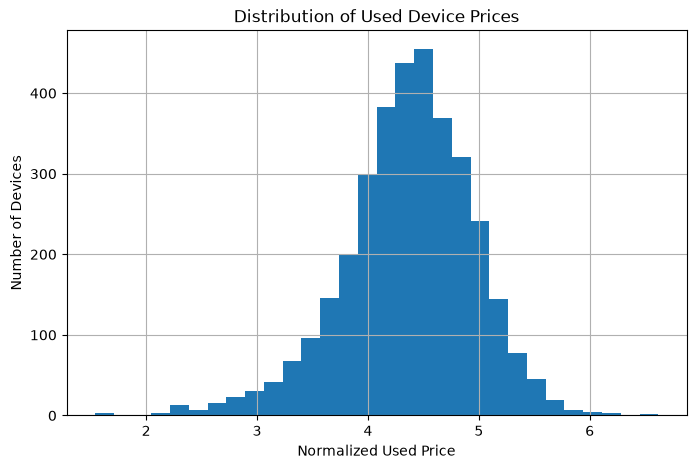

In [51]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/used_device_data.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

df.info()

df.describe()

df.isnull().sum()

print("Duplicate rows:", df.duplicated().sum())

df.head(10)

df.tail()

print("Column names:")
for col in df.columns:
    print("-", col)

missing = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing,
    "Missing Percentage": (missing / len(df) * 100).round(2)
})

missing_summary = missing_summary[missing_summary["Missing Values"] > 0]

missing_summary


print("Number of brands:", df["device_brand"].nunique())
print("\nBrand counts:")
print(df["device_brand"].value_counts())

print(df["os"].value_counts())

print("4G:")
print(df["4g"].value_counts())

print("\n5G:")
print(df["5g"].value_counts())

df["normalized_used_price"].describe()

df["normalized_used_price"].hist(bins=30, figsize=(8, 5))

import matplotlib.pyplot as plt

plt.xlabel("Normalized Used Price")
plt.ylabel("Number of Devices")
plt.title("Distribution of Used Device Prices")
plt.show()

In [54]:
y = df_clean["normalized_used_price"]

target = "normalized_used_price"

features = [
    "device_brand",
    "os",
    "screen_size",
    "4g",
    "5g",
    "rear_camera_mp",
    "front_camera_mp",
    "internal_memory",
    "ram",
    "battery",
    "weight",
    "device_age",
    "days_used",
    "normalized_new_price"
]

X = df_clean[features]
y = df_clean[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

X.dtypes

Features shape: (3454, 14)
Target shape: (3454,)

Features:
['device_brand', 'os', 'screen_size', '4g', '5g', 'rear_camera_mp', 'front_camera_mp', 'internal_memory', 'ram', 'battery', 'weight', 'device_age', 'days_used', 'normalized_new_price']


device_brand                str
os                          str
screen_size             float64
4g                          str
5g                          str
rear_camera_mp          float64
front_camera_mp         float64
internal_memory         float64
ram                     float64
battery                 float64
weight                  float64
device_age                int64
days_used                 int64
normalized_new_price    float64
dtype: object

In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features :", X_test.shape)
print("Training target  :", y_train.shape)
print("Testing target   :", y_test.shape)

categorical_features = [
    "device_brand",
    "os",
    "4g",
    "5g"
]

numerical_features = [
    "screen_size",
    "rear_camera_mp",
    "front_camera_mp",
    "internal_memory",
    "ram",
    "battery",
    "weight",
    "device_age",
    "days_used",
    "normalized_new_price"
]

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

Training features: (2763, 14)
Testing features : (691, 14)
Training target  : (2763,)
Testing target   : (691,)
Categorical features: ['device_brand', 'os', '4g', '5g']
Numerical features: ['screen_size', 'rear_camera_mp', 'front_camera_mp', 'internal_memory', 'ram', 'battery', 'weight', 'device_age', 'days_used', 'normalized_new_price']


In [57]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [61]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

print("Linear Regression pipeline created successfully!")

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

y_pred_linear = linear_model.predict(X_test)

print("Predictions generated:", len(y_pred_linear))

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_linear = mean_absolute_error(y_test, y_pred_linear)

rmse_linear = np.sqrt(
    mean_squared_error(y_test, y_pred_linear)
)

r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("-------------------------")
print(f"MAE  : {mae_linear:.4f}")
print(f"RMSE : {rmse_linear:.4f}")
print(f"R²   : {r2_linear:.4f}")

Linear Regression pipeline created successfully!
Linear Regression model trained successfully!
Predictions generated: 691
Linear Regression Results
-------------------------
MAE  : 0.1841
RMSE : 0.2308
R²   : 0.8359


Random Forest pipeline created successfully!
Random Forest model trained successfully!
Predictions generated: 691
Random Forest Results
--------------------
MAE  : 0.1745
RMSE : 0.2176
R²   : 0.8541


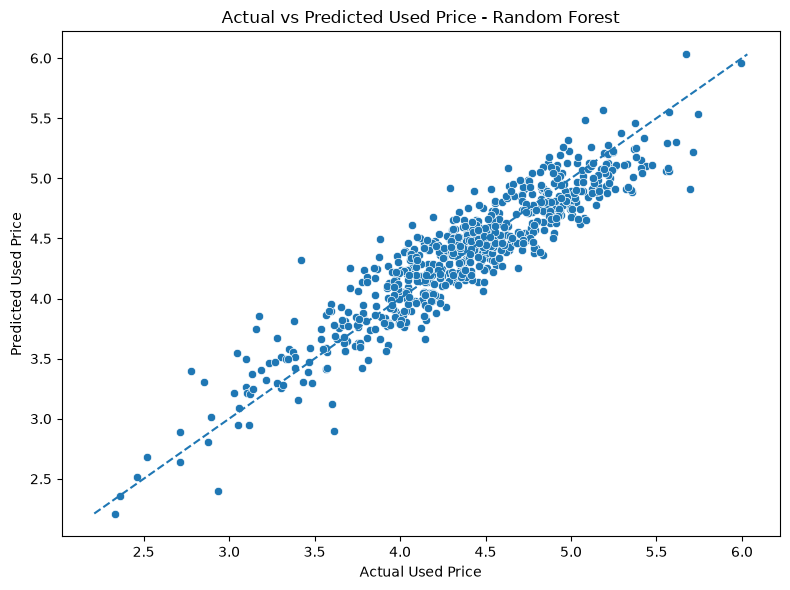

,Actual Price,Predicted Price,Difference
0,3.974246,4.019050,-0.044803
1,5.001191,4.896080,0.105110
2,4.562054,4.289263,0.272790
3,4.176232,4.279817,-0.103586
4,3.156149,3.742826,-0.586677
5,3.777119,4.134847,-0.357728
6,4.932890,4.726103,0.206787
7,5.120924,4.911813,0.209111
8,4.044103,4.097852,-0.053749
9,4.318687,4.581286,-0.262598


In [65]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Random Forest pipeline created successfully!")

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

y_pred_rf = random_forest_model.predict(X_test)

print("Predictions generated:", len(y_pred_rf))

mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("--------------------")
print(f"MAE  : {mae_rf:.4f}")
print(f"RMSE : {rmse_rf:.4f}")
print(f"R²   : {r2_rf:.4f}")


plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred_rf
)

plt.xlabel("Actual Used Price")
plt.ylabel("Predicted Used Price")
plt.title("Actual vs Predicted Used Price - Random Forest")

min_value = min(y_test.min(), y_pred_rf.min())
max_value = max(y_test.max(), y_pred_rf.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.tight_layout()
plt.show()

comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred_rf
})

comparison["Difference"] = (
    comparison["Actual Price"] -
    comparison["Predicted Price"]
)

comparison.head(10)

In [68]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=random_forest_model,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

print("Starting Random Forest tuning...")

grid_search.fit(X_train, y_train)

print("Tuning completed!")
print("Best parameters:")
print(grid_search.best_params_)
print("Best CV R²:", round(grid_search.best_score_, 4))

best_rf = grid_search.best_estimator_

y_pred_best = best_rf.predict(X_test)

mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best = r2_score(y_test, y_pred_best)

print("Tuned Random Forest Results")
print("---------------------------")
print(f"MAE  : {mae_best:.4f}")
print(f"RMSE : {rmse_best:.4f}")
print(f"R²   : {r2_best:.4f}")

Starting Random Forest tuning...
Fitting 5 folds for each of 48 candidates, totalling 240 fits
Tuning completed!
Best parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 500}
Best CV R²: 0.8485
Tuned Random Forest Results
---------------------------
MAE  : 0.1732
RMSE : 0.2153
R²   : 0.8572


Number of processed features: 52


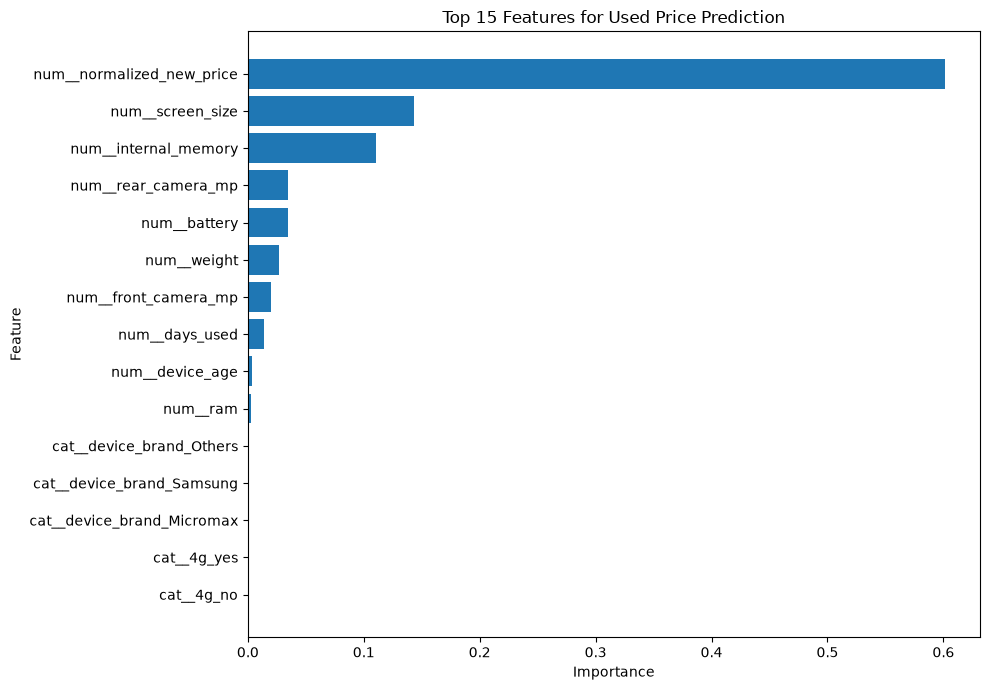

Final model saved successfully!
Location: ../models/smartphone_resale_model.pkl
Model exists: True
Model size: 23401.05 KB


In [72]:
feature_names = best_rf.named_steps["preprocessor"].get_feature_names_out()

print("Number of processed features:", len(feature_names))

importances = best_rf.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features for Used Price Prediction")
plt.tight_layout()
plt.show()

import joblib

model_path = "../models/smartphone_resale_model.pkl"

joblib.dump(best_rf, model_path)

print("Final model saved successfully!")
print("Location:", model_path)

import os

print("Model exists:", os.path.exists(model_path))
print("Model size:", round(os.path.getsize(model_path) / 1024, 2), "KB")